In [47]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
username = "manikya.pant"

In [48]:
class GMM:
    def __init__(self, n_components, max_iter=100, tol=1e-4):
        self.n_components = n_components
        self.max_iter = max_iter
        self.tol = tol
        self.weights = None
        self.means = None
        self.covariances = None
        self.log_likelihoods = []

    def pdf(self, X, mean, cov):
        """
        Calculates the probability density function of a multivariate Gaussian.
        """
        n_features = X.shape[1]
        
        # Add a small epsilon to the diagonal for numerical stability
        epsilon = 1e-6
        cov_reg = cov + np.eye(n_features) * epsilon
        
        det_cov = np.linalg.det(cov_reg)
        
        # Check for non-positive determinant
        if det_cov <= 0:
            return np.zeros(X.shape[0])
            
        inv_cov = np.linalg.inv(cov_reg)
        coeff = 1 / np.sqrt((2 * np.pi) ** n_features * det_cov)
        diff = X - mean
        exponent = -0.5 * np.sum((diff @ inv_cov) * diff, axis=1)
        
        return coeff * np.exp(exponent)

    def initialize_parameters(self, data):
        """Initializes the GMM parameters (means, covariances, weights)."""
        n_samples, n_features = data.shape
        
        # 1. Randomly select data points as initial means
        random_indices = np.random.choice(n_samples, self.n_components, replace=False)
        self.means = data[random_indices]

        # 2. Initialize covariances as identity matrices
        self.covariances = [np.eye(n_features) for _ in range(self.n_components)]

        # 3. Initialize weights uniformly
        self.weights = np.ones(self.n_components) / self.n_components
        
        # Clear log likelihoods from previous fits
        self.log_likelihoods = []

    def _e_step(self, data):
        """
        Performs the E-step of the EM algorithm.
        Calculates the responsibilities and the log-likelihood.
        """
        n_samples = data.shape[0]
        responsibilities = np.zeros((n_samples, self.n_components))

        for k in range(self.n_components):
            # Calculate the likelihood of each data point for component k
            likelihood = self.pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * likelihood
        
        # Calculate the sum of responsibilities for normalization and log-likelihood
        responsibilities_sum = responsibilities.sum(axis=1, keepdims=True) + 1e-8
        
        # Calculate the log-likelihood for the current iteration
        log_likelihood = np.sum(np.log(responsibilities_sum))
        
        # Normalize the responsibilities
        responsibilities /= responsibilities_sum
        
        return responsibilities, log_likelihood

    def _m_step(self, data, responsibilities):
        """
        Performs the M-step of the EM algorithm.
        Updates the parameters (means, covariances, weights).
        """
        n_samples, n_features = data.shape
        
        # Sum of responsibilities for each component
        N_k = responsibilities.sum(axis=0)
        
        # 1. Update weights
        self.weights = N_k / n_samples
        
        # 2. Update means
        self.means = (responsibilities.T @ data) / N_k[:, np.newaxis]
        
        # 3. Update covariances
        regularization = 1e-6 * np.eye(n_features) # For numerical stability
        for k in range(self.n_components):
            diff = data - self.means[k]
            # Vectorized way to compute sum of weighted outer products
            weighted_sum = (responsibilities[:, k][:, np.newaxis] * diff).T @ diff
            self.covariances[k] = weighted_sum / N_k[k] + regularization

    def fit(self, data):
        """
        Fits the GMM to the data by running the full EM algorithm.
        """
        # 1. Initialize parameters
        self.initialize_parameters(data)
        
        # Initialize log-likelihood for convergence check
        log_likelihood = -np.inf 

        for iteration in range(self.max_iter):
            # 2. Perform E-Step
            responsibilities, new_log_likelihood = self._e_step(data)
            
            # 3. Perform M-Step
            self._m_step(data, responsibilities)
            
            # 4. Store log-likelihood for plotting
            self.log_likelihoods.append(new_log_likelihood)
            
            # 5. Check for convergence
            if abs(new_log_likelihood - log_likelihood) < self.tol:
                print(f"Converged at iteration {iteration+1}")
                break
            
            log_likelihood = new_log_likelihood

        print("Fitting complete.")
    
    def getMembership(self, data):
        """
        Returns the membership values (probabilities) for each sample.
        """
        if self.means is None:
            raise RuntimeError("You must fit the model before getting memberships.")
        
        responsibilities = np.zeros((data.shape[0], self.n_components))
        for k in range(self.n_components):
            pdf_vals = self.pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * pdf_vals
            
        responsibilites_sum = responsibilities.sum(axis=1, keepdims=True)
        # Normalize to get probabilities
        memberships = responsibilities / (responsibilites_sum + 1e-9)
        return memberships

    def getLikelihood(self, data):
        """
        Returns the overall log-likelihood of the dataset under the current model.
        """
        if self.means is None:
            raise RuntimeError("You must fit the model before getting the likelihood.")
        
        responsibilities = np.zeros((data.shape[0], self.n_components))
        for k in range(self.n_components):
            pdf_vals = self.pdf(data, self.means[k], self.covariances[k])
            responsibilities[:, k] = self.weights[k] * pdf_vals
            
        # The likelihood for each point is the sum of weighted PDFs
        likelihood_per_sample = responsibilities.sum(axis=1)
        
        # The total log-likelihood is the sum of the logs of these likelihoods
        total_log_likelihood = np.sum(np.log(likelihood_per_sample + 1e-9))
        return total_log_likelihood

    def drawLikelihood(self):
        """
        Draws the plot of log-likelihood vs. iterations.
        """
        if not self.log_likelihoods:
            raise RuntimeError("You must fit the model before drawing the likelihood plot.")
            
        plt.figure(figsize=(8, 6))
        plt.plot(range(1, len(self.log_likelihoods) + 1), self.log_likelihoods, marker='o', linestyle='-')
        plt.title('Log-Likelihood vs. Iterations')
        plt.xlabel('Iteration')
        plt.ylabel('Log-Likelihood')
        plt.grid(True)
        plt.show()
    

    def predict(self, data):
        """Predict the cluster for each data point based on highest membership."""
        memberships = self.getMembership(data)
        return np.argmax(memberships, axis=1)



Converged at iteration 78
Fitting complete.


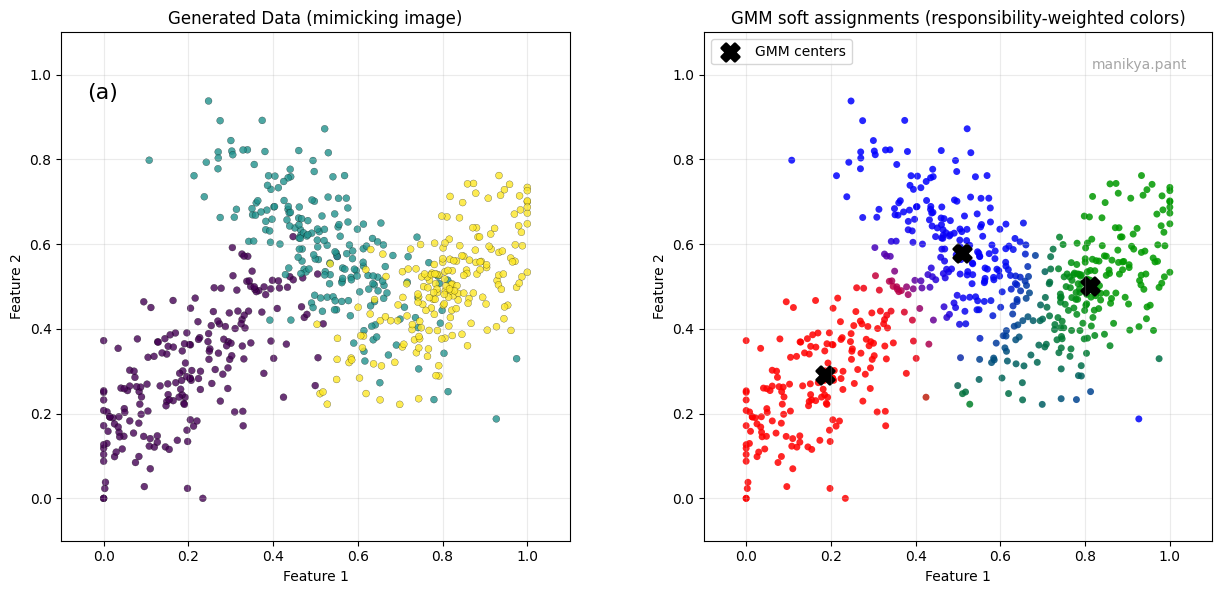

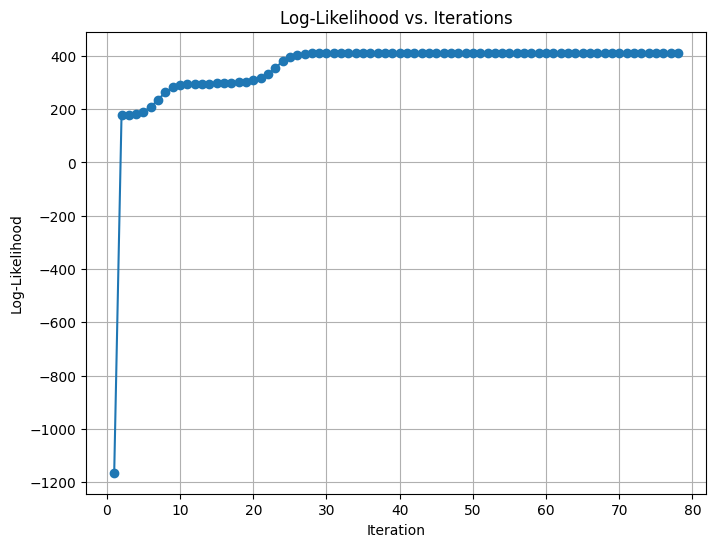

In [50]:
# working on a sample data

def rotated_cov(angle_deg, long_var, short_var):
    theta = np.deg2rad(angle_deg)
    R = np.array([[np.cos(theta), -np.sin(theta)],
                  [np.sin(theta),  np.cos(theta)]])
    D = np.diag([long_var, short_var])
    return R @ D @ R.T

# Adjusting means and covariances to mimic the provided image
means = np.array([
    [0.2, 0.3],   # Red cluster (bottom-left)
    [0.5, 0.6],   # Green cluster (middle-top)
    [0.8, 0.5]    # Blue cluster (top-right)
])

covs = [
    rotated_cov(45, long_var=0.03, short_var=0.005),  # Red: elongated bottom-left to top-right
    rotated_cov(-45, long_var=0.035, short_var=0.005), # Green: elongated top-left to bottom-right
    rotated_cov(45, long_var=0.03, short_var=0.005)   # Blue: elongated bottom-left to top-right
]

n_per_comp = 200 # Fewer points per component for a less dense look
X_parts = [np.random.multivariate_normal(means[i], covs[i], n_per_comp) for i in range(3)]
X = np.vstack(X_parts)
y_true = np.hstack([[i]*n_per_comp for i in range(3)])

# Clip data to simulate bounded area (0 to 1)
X = np.clip(X, 0, 1)

gmm = GMM(n_components=3, max_iter=200)
gmm.fit(X)
responsibilities = gmm.getMembership(X)
centers = gmm.means


# Define base colors for components (matching the image: Red, Green, Blue)
base_colors = np.array([[1,0,0],[0,0.6,0],[0,0,1.0]])  # Red, Green, Blue
# Soft blended color per point
point_colors = responsibilities @ base_colors
point_colors = np.clip(point_colors, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(13,6))

# Original data with true labels (hard coloring)
axes[0].scatter(X[:,0], X[:,1], c=y_true, cmap='viridis', s=25, alpha=0.8, edgecolor='k', linewidth=0.2)
axes[0].set_title("Generated Data (mimicking image)")
axes[0].set_xlabel("Feature 1")
axes[0].set_ylabel("Feature 2")
axes[0].grid(alpha=0.25)
axes[0].set_aspect('equal', adjustable='box') # Make axes equal for correct visual aspect
axes[0].set_xlim(-0.1, 1.1) # Set limits to match image
axes[0].set_ylim(-0.1, 1.1)
axes[0].text(0.05, 0.9, '(a)', transform=axes[0].transAxes, fontsize=16, va='top', ha='left') # Add (a) label


# GMM result with soft responsibilities (blended colors) and centers
axes[1].scatter(X[:,0], X[:,1], color=point_colors, s=25, alpha=0.85, edgecolor='none')
axes[1].scatter(centers[:,0], centers[:,1], c='black', marker='X', s=160, linewidths=2, label='GMM centers')
axes[1].set_title("GMM soft assignments (responsibility-weighted colors)")
axes[1].set_xlabel("Feature 1")
axes[1].set_ylabel("Feature 2")
axes[1].legend()
axes[1].grid(alpha=0.25)
axes[1].set_aspect('equal', adjustable='box') # Make axes equal for correct visual aspect
axes[1].set_xlim(-0.1, 1.1) # Set limits to match image
axes[1].set_ylim(-0.1, 1.1)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.tight_layout()
plt.show()

gmm.drawLikelihood()

Converged at iteration 22
Fitting complete.


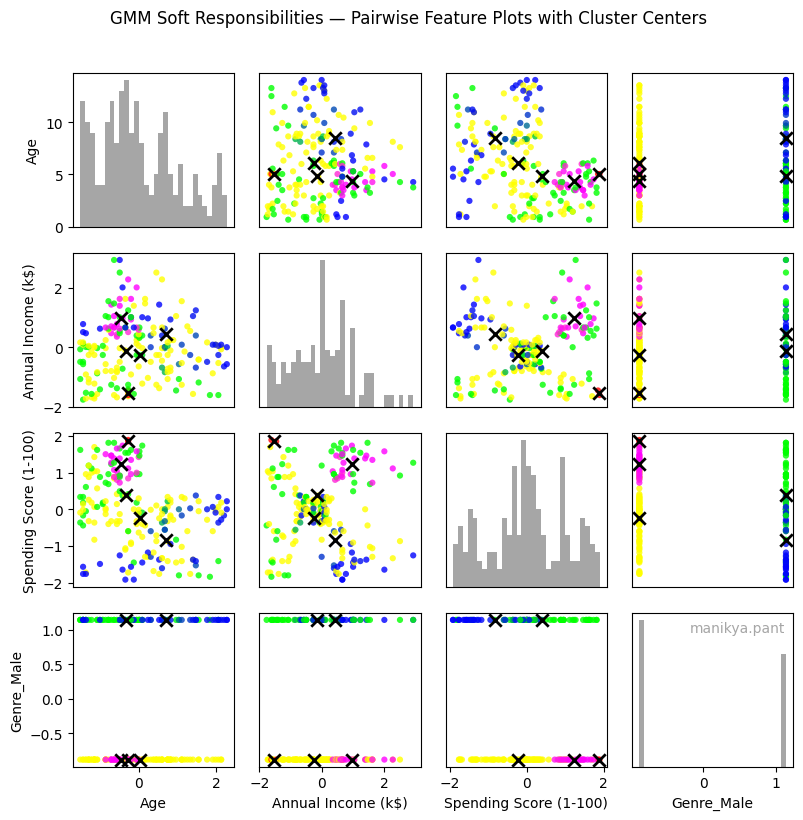

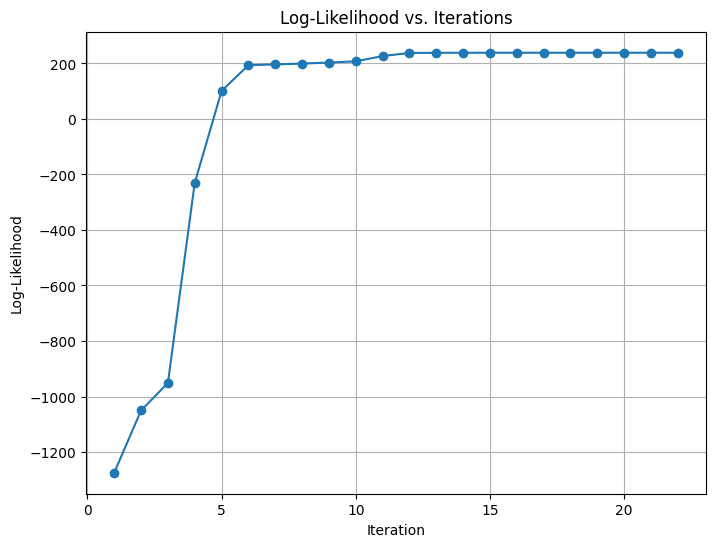

In [51]:
df = pd.read_csv('Clustering_dataset(in).csv')

# changing numeric colums to mean for missing values and categorical to mode
for column in df.columns:
    if df[column].dtype == 'object':
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].mean())

df = pd.get_dummies(df, drop_first=True)

# can drop the customer ID column as it is not useful for clustering
if 'CustomerID' in df.columns:
    df = df.drop('CustomerID', axis=1)

scaler = StandardScaler()


X_scaled = scaler.fit_transform(df)


gmm = GMM(n_components=5, max_iter=100)
gmm.fit(X_scaled) # Use the scaled data here



responsibilities = gmm.getMembership(X_scaled)

# Define base cluster colors (RGB)
colors = np.array([
    [1, 0, 0],   # Red
    [0, 1, 0],   # Green
    [0, 0, 1],   # Blue
    [1, 1, 0],   # Yellow
    [1, 0, 1]    # Magenta
])

# Weighted blend per point
point_colors = responsibilities @ colors
point_colors = np.clip(point_colors, 0, 1)

# Prepare feature names
features = df.columns
n_features = len(features)

# Make a grid of subplots
fig, axes = plt.subplots(n_features, n_features, figsize=(2*n_features, 2*n_features))

for i in range(n_features):
    for j in range(n_features):
        ax = axes[i, j]
        if i == j:
            # Histogram on diagonal
            ax.hist(X_scaled[:, i], bins=30, color="gray", alpha=0.7)
        else:
            # Scatter for feature pairs
            ax.scatter(X_scaled[:, j], X_scaled[:, i], c=point_colors, s=20, alpha=0.8, edgecolor="none")
            
            # Overlay cluster centers
            for mean in gmm.means:
                ax.scatter(mean[j], mean[i], c="black", marker="x", s=80, linewidths=2)

        # Labels
        if i == n_features - 1:
            ax.set_xlabel(features[j])
        else:
            ax.set_xticks([])

        if j == 0:
            ax.set_ylabel(features[i])
        else:
            ax.set_yticks([])

plt.suptitle("GMM Soft Responsibilities — Pairwise Feature Plots with Cluster Centers", y=1.02)
plt.tight_layout()
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

gmm.drawLikelihood()


Converged at iteration 34
Fitting complete.
Converged at iteration 44
Fitting complete.
Converged at iteration 40
Fitting complete.
Converged at iteration 27
Fitting complete.
Converged at iteration 62
Fitting complete.
Fitting complete.
Converged at iteration 79
Fitting complete.
Converged at iteration 55
Fitting complete.
Fitting complete.


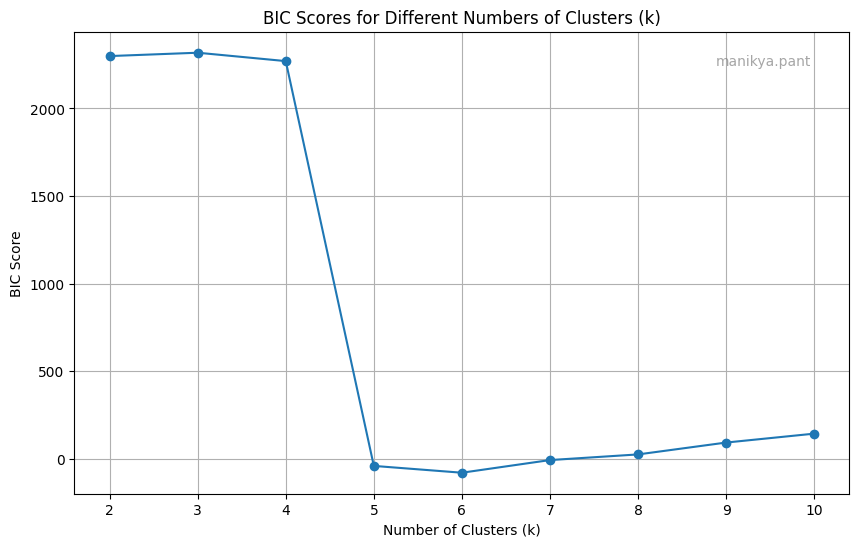

Optimal k according to BIC is: 6


In [56]:
# Define a range of k values to test
from sklearn.metrics import silhouette_score
k_range = range(2, 11) 
bic_scores = []
n_samples, n_features = X_scaled.shape

for k in k_range:
    gmm = GMM(n_components=k, max_iter=100)
    gmm.fit(X_scaled)
    
    # Get the log-likelihood from the last iteration
    log_likelihood = gmm.log_likelihoods[-1]
    
    # Calculate the number of free parameters (p)
    # Weights: k-1
    # Means: k * n_features
    # Covariances: k * n_features * (n_features + 1) / 2
    n_params = (k - 1) + (k * n_features) + (k * n_features * (n_features + 1) / 2)
    
    # Calculate BIC
    bic = np.log(n_samples) * n_params - 2 * log_likelihood
    bic_scores.append(bic)


# Plot the BIC scores
plt.figure(figsize=(10, 6))
plt.plot(k_range, bic_scores, marker='o', linestyle='-')
plt.title('BIC Scores for Different Numbers of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC Score')
plt.xticks(k_range)
plt.grid(True)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

# Find the optimal k
optimal_k_bic = k_range[np.argmin(bic_scores)]
print(f"Optimal k according to BIC is: {optimal_k_bic}")

Converged at iteration 67
Fitting complete.
Converged at iteration 29
Fitting complete.
Converged at iteration 27
Fitting complete.
Converged at iteration 74
Fitting complete.
Converged at iteration 73
Fitting complete.
Converged at iteration 93
Fitting complete.
Fitting complete.
Converged at iteration 52
Fitting complete.
Converged at iteration 61
Fitting complete.


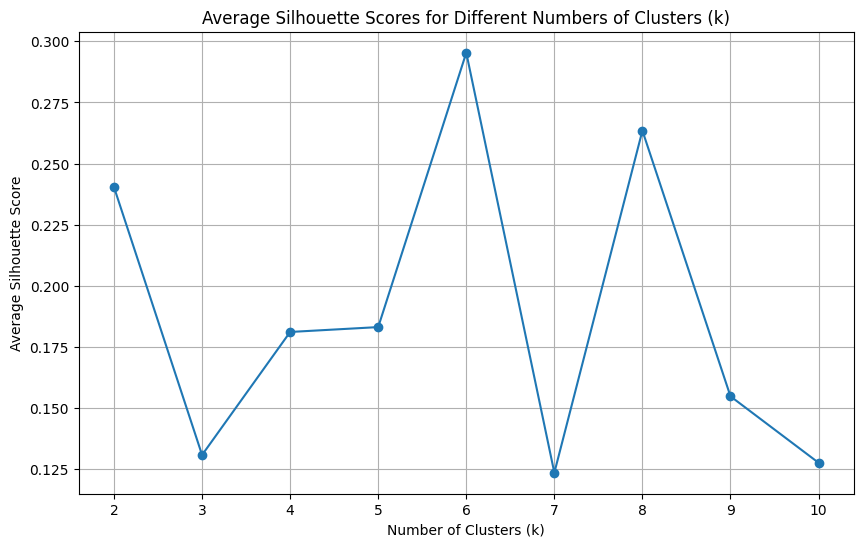

Optimal k according to the Silhouette Method is: 6


In [ ]:

k_range = range(2, 11)
silhouette_scores = []

for k in k_range:
    gmm = GMM(n_components=k, max_iter=100)
    gmm.fit(X_scaled)
    
    # Predict the cluster labels for each data point
    labels = gmm.predict(X_scaled)
    
    if len(np.unique(labels)) > 1:
        score = silhouette_score(X_scaled, labels)
        silhouette_scores.append(score)

        
plt.figure(figsize=(10, 6))
plt.plot(k_range, silhouette_scores, marker='o', linestyle='-')
plt.title('Average Silhouette Scores for Different Numbers of Clusters (k)')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Average Silhouette Score')
plt.xticks(k_range)
plt.grid(True)
plt.text(
    0.95, 0.95, username,
    ha='right', va='top',
    transform=plt.gca().transAxes,
    fontsize=10, color='gray', alpha=0.7
)
plt.show()

# Find the optimal k
optimal_k_silhouette = k_range[np.argmax(silhouette_scores)]
print(f"Optimal k according to the Silhouette Method is: {optimal_k_silhouette}")